# Gráficos: EPH Gran La Plata e IAELaP Partido de La Plata

Arma los gráficos que sí se pueden construir ya con los datos disponibles, sin dos cosas que quedan para otra etapa: **ninguna distribución espacial** de La Plata (no sabemos todavía a qué localidad pertenece cada circuito electoral) y **ningún cruce entre resultados electorales y datos socioeconómicos**.

Fuentes:
- `data/socioeconomia/eph_gran_la_plata.csv` — 35 trimestres reales, 2017T2-2025T4 (notebook 05).
- `data/socioeconomia/iaelap_la_plata.csv` / `iaelap_la_plata_ramas.csv` — Indicador de Actividad Económica de La Plata (UNLP-FCE), relevado en esta sesión leyendo boletines PDF con el tool `Read` (WebFetch no puede leerlos — son PDF de diseño, no texto plano). Ver `data/socioeconomia/EXTRACCION_IAELAP.md` para el catálogo completo de boletines y un hallazgo importante: **IAELaP revisa su serie retrospectiva entre boletines** — este dataset usa siempre el valor del boletín más reciente disponible para cada trimestre, documentado en la columna `boletin_fuente`.

**EPH = aglomerado Gran La Plata (La Plata+Berisso+Ensenada). IAELaP = Partido de La Plata solo.** Geografías distintas — el gráfico de contraste las presenta en paneles separados, nunca superpuestas en un mismo eje.

## Convención visual: cortes metodológicos

Todos los gráficos de serie temporal de la EPH (menos los de IAELaP, que son otra fuente/rango temporal) marcan automáticamente los cortes metodológicos conocidos de la serie (`marcar_cortes=True` por default, ver `_marcar_cortes_metodologicos` en `graficos_eph_iaelap.py`):

- **Banda gris**: hueco sin dato (2015T3-2016T1, INDEC no publicó) + cambio de fuente/ponderación (DBF histórico -> bases actuales INDEC), representados juntos porque ocurren en el mismo punto de la serie.
- **Línea punteada, 2020**: cambio de operativo EPH (encuesta telefónica por la pandemia).
- **Línea punteada, 2023T4** (solo en el gráfico de estrategias de subsistencia): split de la pregunta `V5` en `V5_01/02/03`, reconstruida en `eph_client.py`.

Ninguna de estas marcas cambia los datos -- son señales visuales para no leer una ruptura de método como si fuera una tendencia real.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO / "src"))

from socioeconomia import graficos_eph_iaelap as g

DATOS = REPO / "data" / "socioeconomia"
SALIDA = REPO / "graficos" / "socioeconomia"
SALIDA.mkdir(parents=True, exist_ok=True)
# Los gráficos de la EPH (a diferencia de los de IAELaP y el de contraste) se versionan
# en git -- van a su propia subcarpeta, la única excepción a graficos/ en .gitignore
# además de graficos/distrito/serie_temporal/.
SALIDA_EPH = SALIDA / "eph"
SALIDA_EPH.mkdir(parents=True, exist_ok=True)

## 1. EPH Gran La Plata — desocupación e informalidad

Dos series de línea sobre un único eje (ambas son %, comparables sin normalizar). No se grafica el ingreso (`ingreso_ocupacion_principal_medio_todos_ocupados`/`_perceptores`/`ipcf_medio`): son valores corrientes (nominales), no deflactados — con la inflación del período, su nivel a través del tiempo sin una serie de precios sería engañoso. Falta un IPC en el repo para eso (ver README).

guardado: /workspaces/analisis-politica-economia/graficos/socioeconomia/eph/eph_desocupacion_informalidad.png


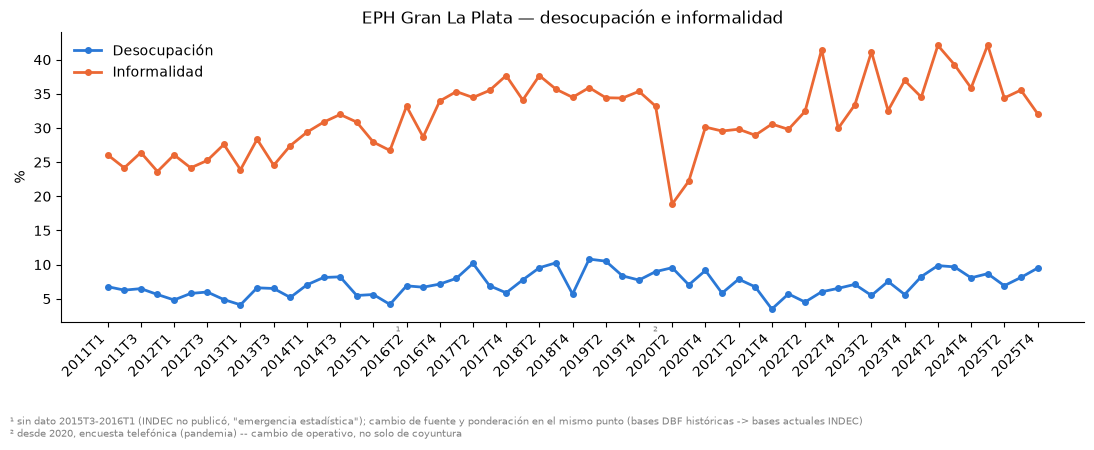

In [2]:
fig = g.graficar_desocupacion_informalidad(DATOS)
fig.savefig(SALIDA_EPH / "eph_desocupacion_informalidad.png", dpi=150)
print("guardado:", SALIDA_EPH / "eph_desocupacion_informalidad.png")

## 1.1 EPH Gran La Plata — indicadores ampliados

A partir de `eph_gran_la_plata.csv` (ahora con ~25 columnas, 2011-2025) y de los CSV nuevos `eph_gran_la_plata_por_sexo.csv`/`_por_edad.csv`. Todos calculados desde los microdatos crudos con `src/socioeconomia/eph_client.py` — no hay ningún dato inventado, cada indicador sale de una variable puntual de la EPH (ver el inventario completo discutido en esta sesión: `CH04`/`CH06` para sexo/edad, `CAT_OCUP`, `PP07G1/G2/G4`, `CH08`, `NIVEL_ED`, `CH09`, `CH10`, `II1`/`IX_TOT`, `IV7`, `II7`, `V5`/`V15`/`V17`).

### Actividad y empleo (no solo desocupación)

guardado: eph_actividad_empleo.png


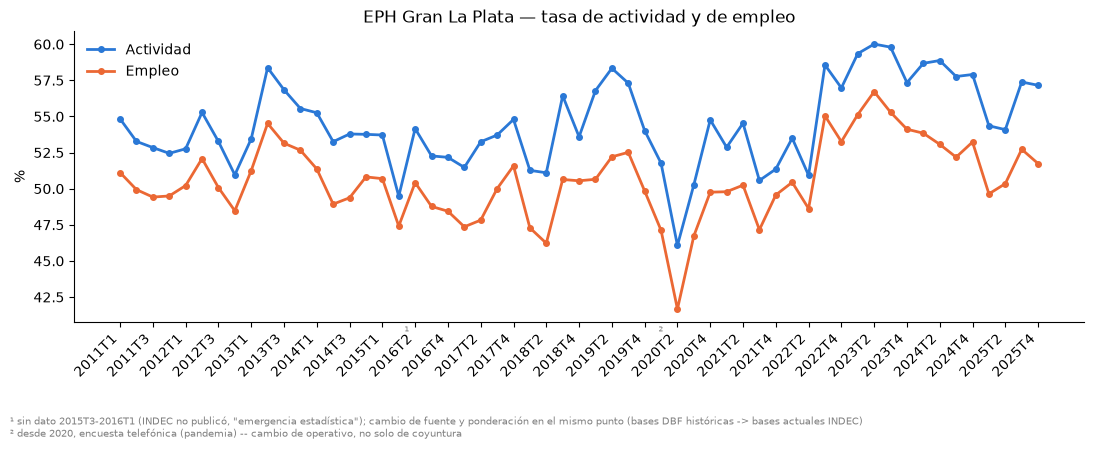

In [3]:
fig = g.graficar_tasas_actividad_empleo(DATOS)
fig.savefig(SALIDA_EPH / "eph_actividad_empleo.png", dpi=150)
print("guardado: eph_actividad_empleo.png")

### Calidad del empleo asalariado

guardado: eph_calidad_empleo.png


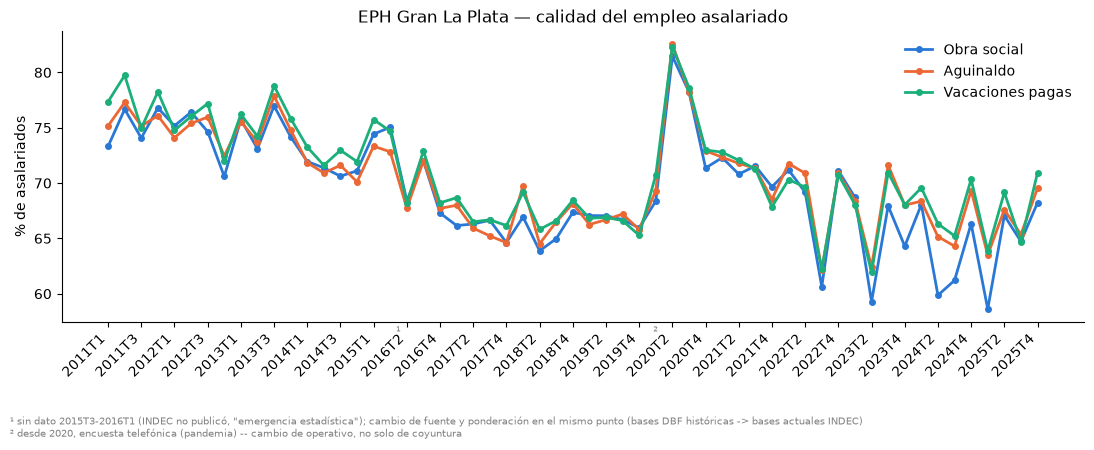

In [4]:
fig = g.graficar_calidad_empleo(DATOS)
fig.savefig(SALIDA_EPH / "eph_calidad_empleo.png", dpi=150)
print("guardado: eph_calidad_empleo.png")

### Cobertura de salud

guardado: eph_cobertura_salud.png


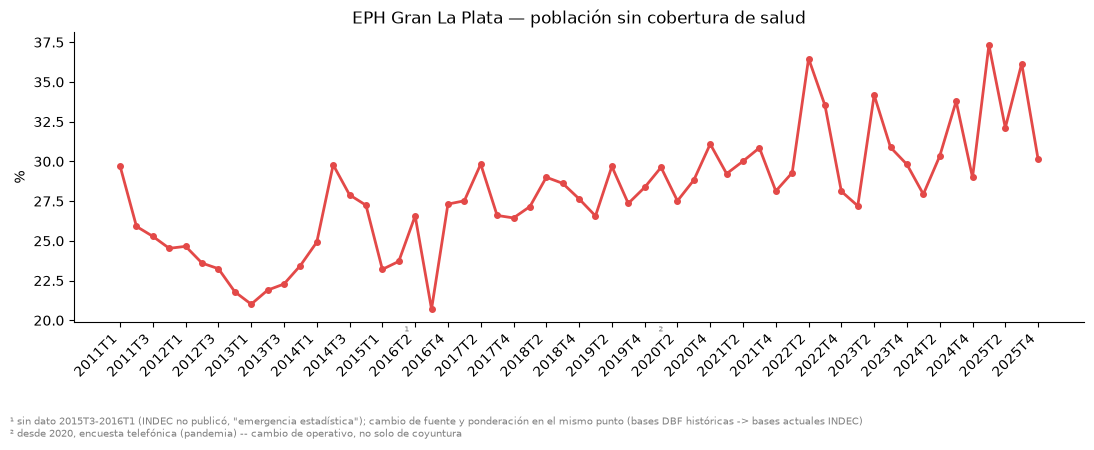

In [5]:
fig = g.graficar_cobertura_salud(DATOS)
fig.savefig(SALIDA_EPH / "eph_cobertura_salud.png", dpi=150)
print("guardado: eph_cobertura_salud.png")

### Educación

guardado: eph_educacion.png


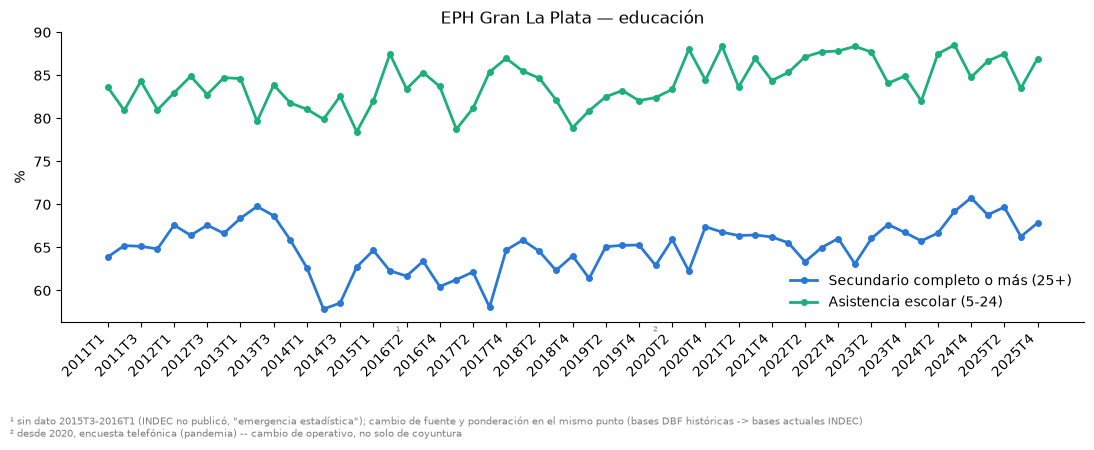

In [6]:
fig = g.graficar_educacion(DATOS)
fig.savefig(SALIDA_EPH / "eph_educacion.png", dpi=150)
print("guardado: eph_educacion.png")

### Hacinamiento

guardado: eph_hacinamiento.png


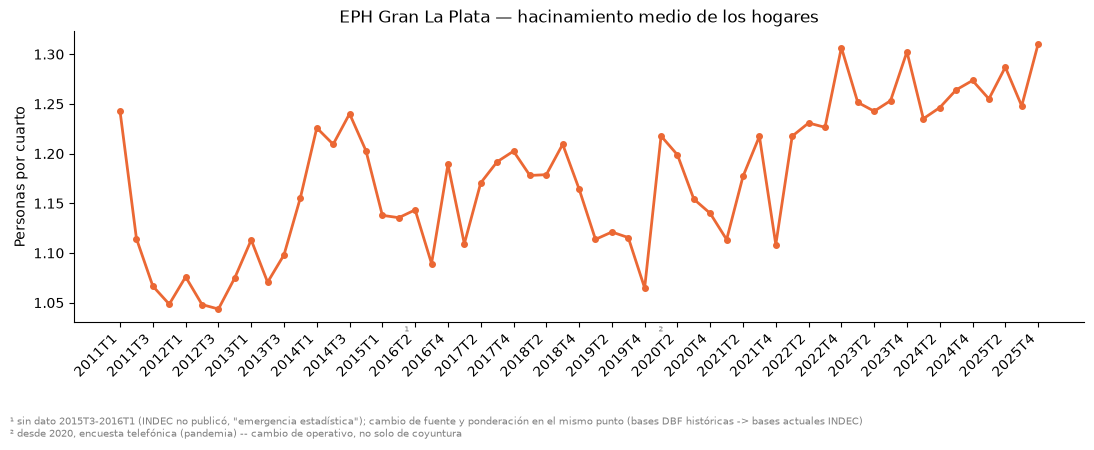

In [7]:
fig = g.graficar_hacinamiento(DATOS)
fig.savefig(SALIDA_EPH / "eph_hacinamiento.png", dpi=150)
print("guardado: eph_hacinamiento.png")

### Estrategias de subsistencia del hogar

guardado: eph_estrategias_subsistencia.png


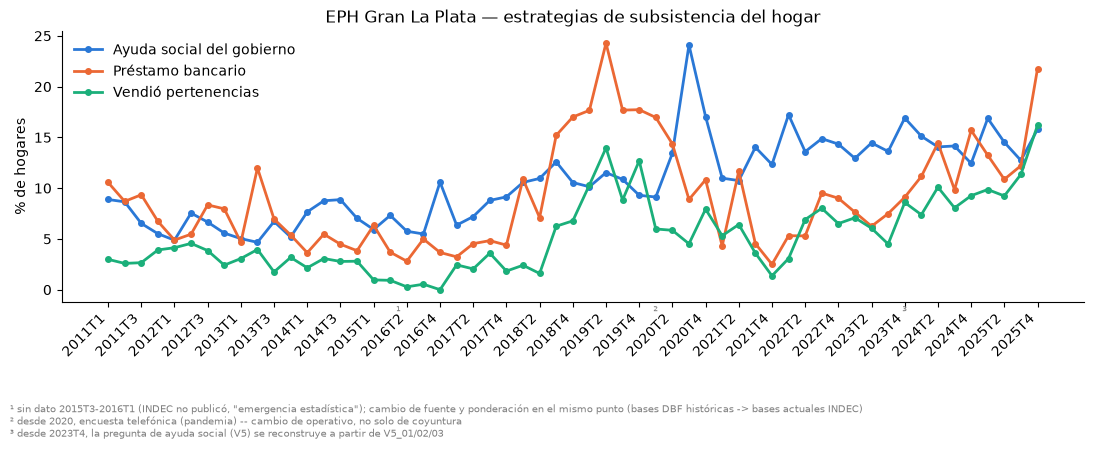

In [8]:
fig = g.graficar_estrategias_subsistencia(DATOS)
fig.savefig(SALIDA_EPH / "eph_estrategias_subsistencia.png", dpi=150)
print("guardado: eph_estrategias_subsistencia.png")

### Brecha de género

Mismos indicadores del núcleo laboral, abiertos por sexo (`CH04`).

### General — desocupación, informalidad y actividad (sin desagregar por sexo)

Contraparte de cada gráfico de "brecha de género" de más abajo, pero con la
población total (no varones/mujeres por separado) — para poder mirar la
serie general de cada indicador sin tener que reconstruirla mentalmente a
partir del desagregado por sexo.

guardados: eph_desocupacion.png, eph_informalidad.png, eph_actividad.png


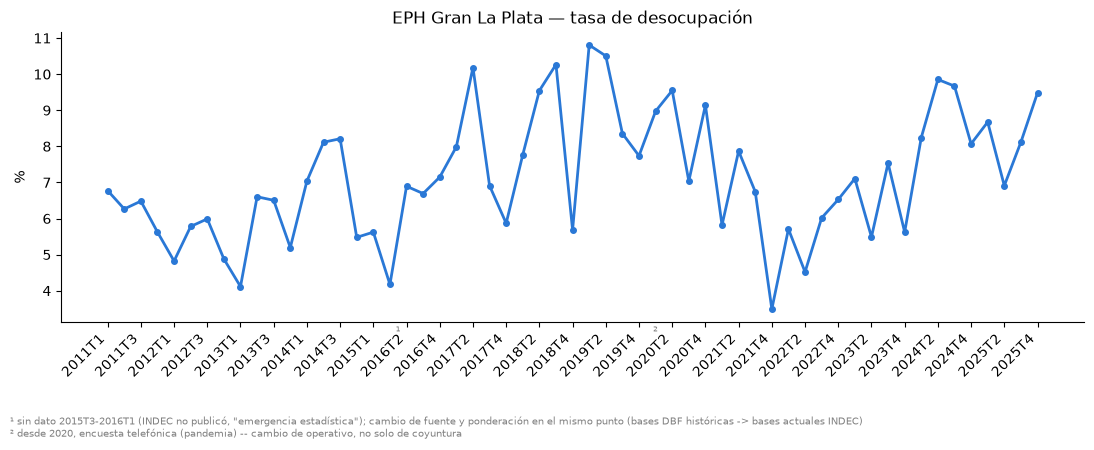

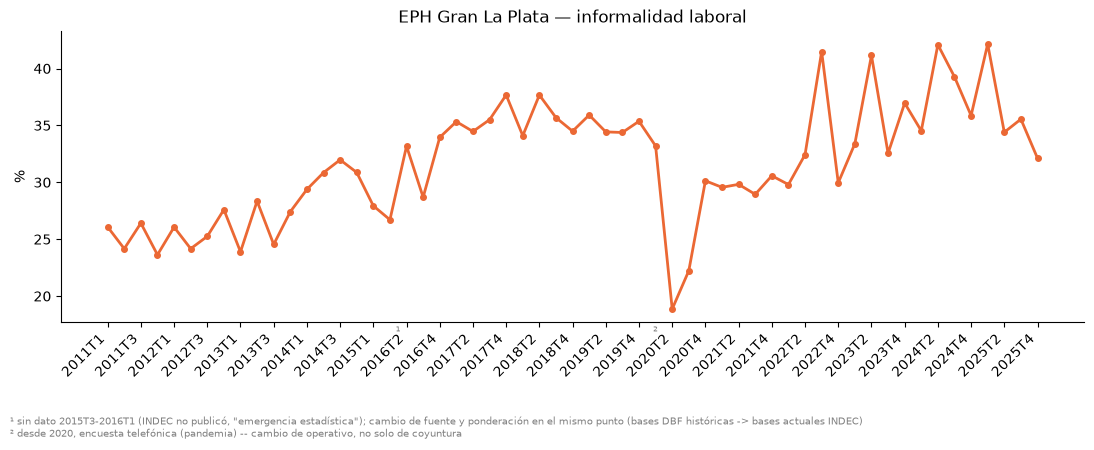

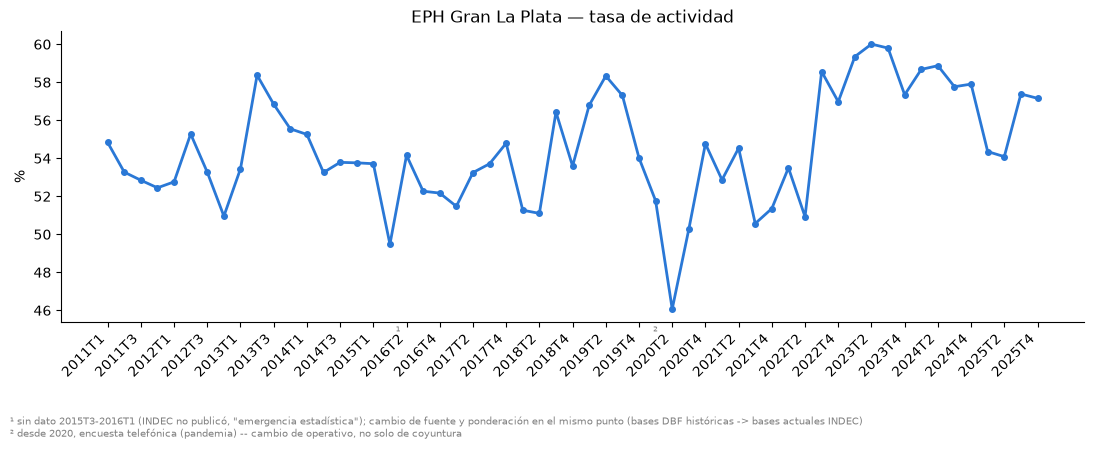

In [9]:
fig = g.graficar_desocupacion(DATOS)
fig.savefig(SALIDA_EPH / "eph_desocupacion.png", dpi=150)

fig = g.graficar_informalidad(DATOS)
fig.savefig(SALIDA_EPH / "eph_informalidad.png", dpi=150)

fig = g.graficar_actividad(DATOS)
fig.savefig(SALIDA_EPH / "eph_actividad.png", dpi=150)
print("guardados: eph_desocupacion.png, eph_informalidad.png, eph_actividad.png")

guardados: eph_brecha_genero_*.png


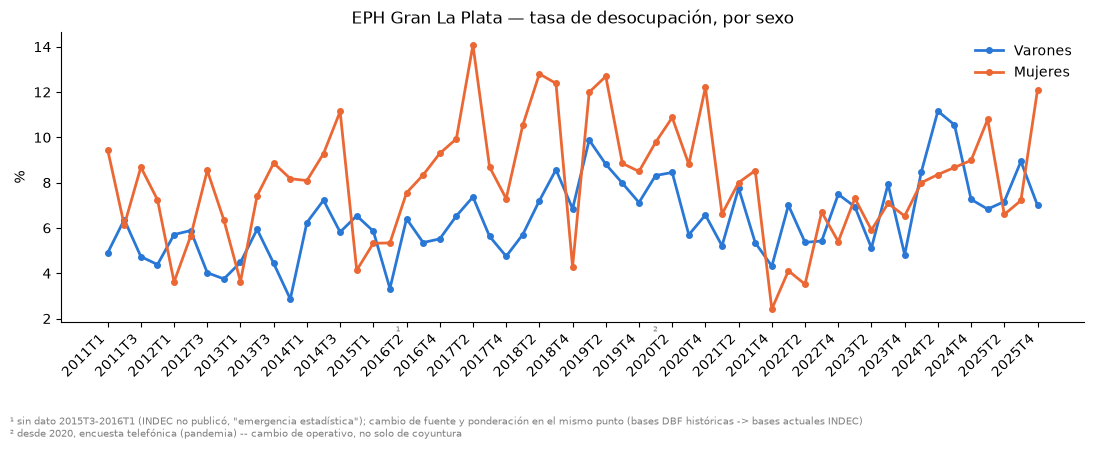

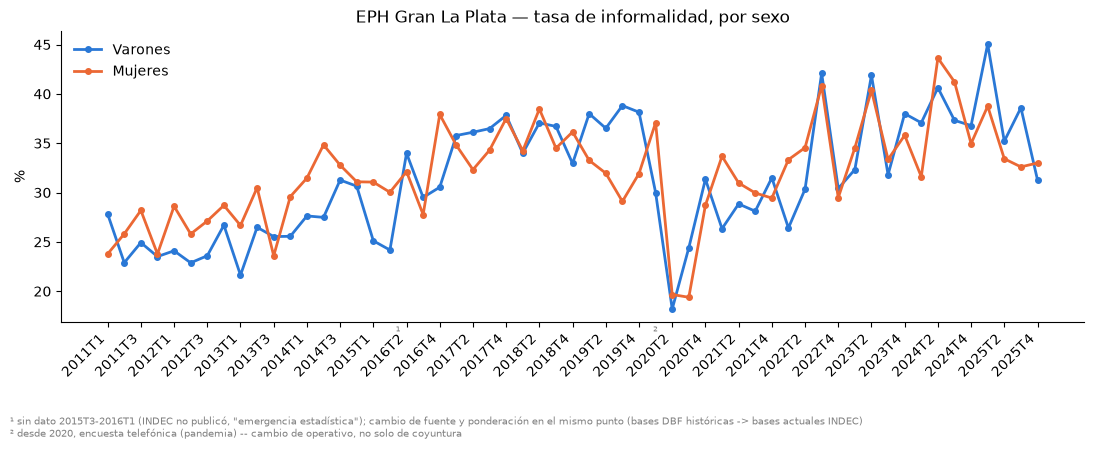

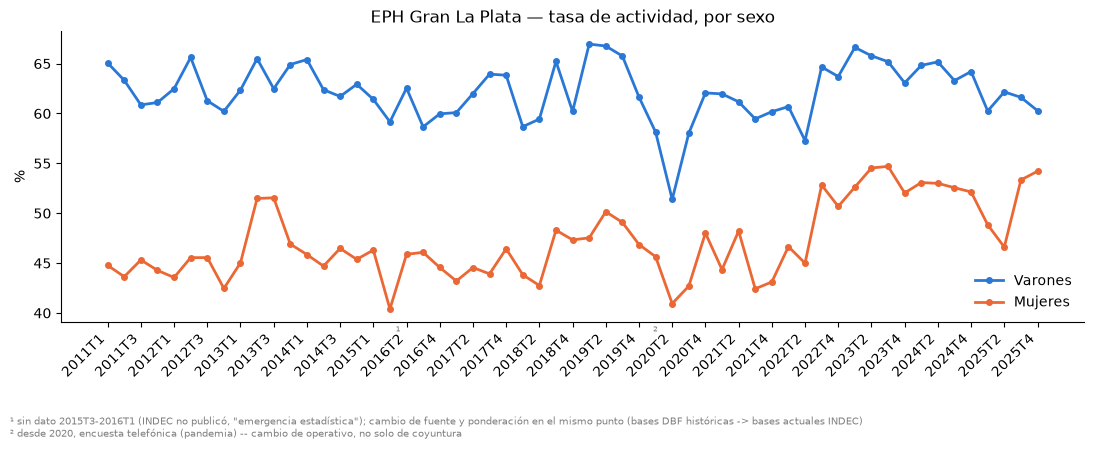

In [10]:
fig = g.graficar_brecha_genero(DATOS, "tasa_desocupacion", "tasa de desocupación")
fig.savefig(SALIDA_EPH / "eph_brecha_genero_desocupacion.png", dpi=150)

fig = g.graficar_brecha_genero(DATOS, "tasa_informalidad", "tasa de informalidad")
fig.savefig(SALIDA_EPH / "eph_brecha_genero_informalidad.png", dpi=150)

fig = g.graficar_brecha_genero(DATOS, "tasa_actividad", "tasa de actividad")
fig.savefig(SALIDA_EPH / "eph_brecha_genero_actividad.png", dpi=150)
print("guardados: eph_brecha_genero_*.png")

### Desocupación por tramo etario

Pequeños múltiplos (no 4 líneas superpuestas — 4 series no pasan la validación de paleta all-pairs, ver docstring de `graficos_eph_iaelap.py`).

guardado: eph_desocupacion_por_edad.png


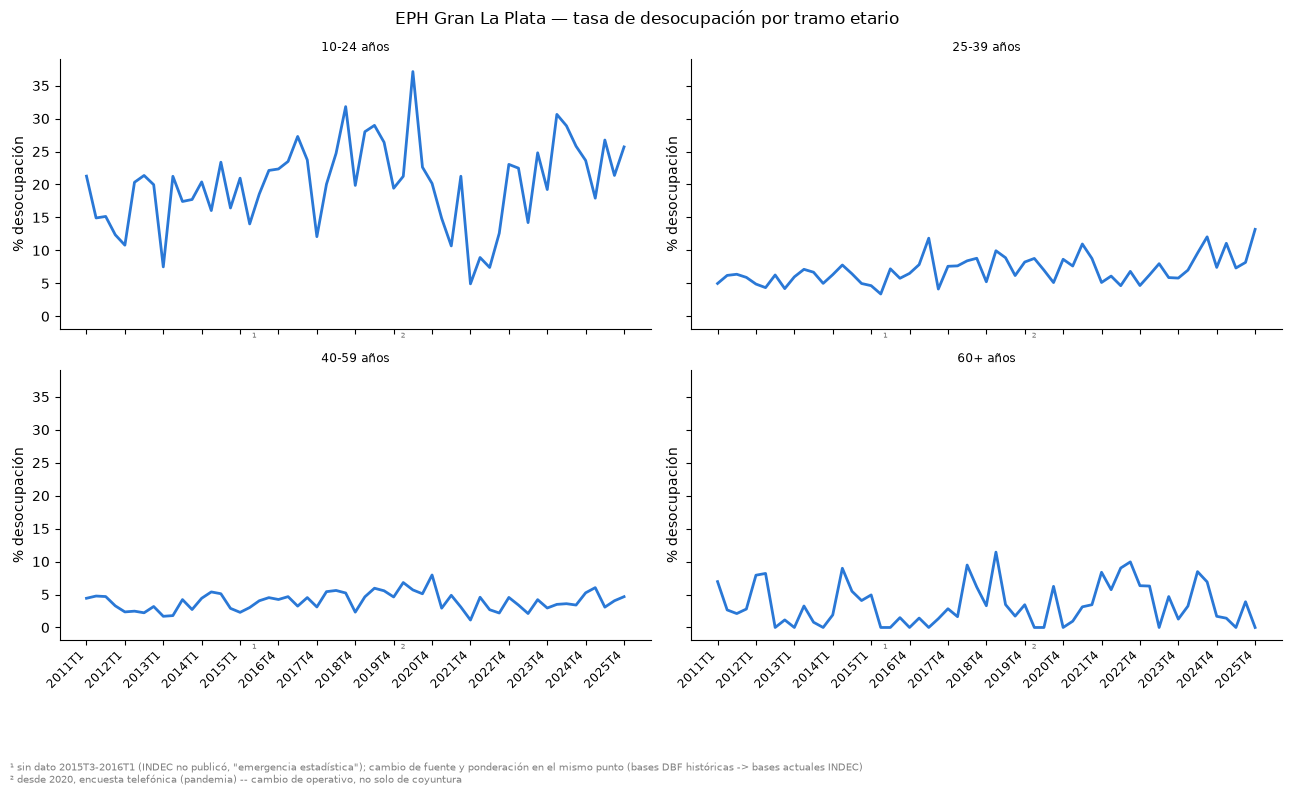

In [11]:
fig = g.graficar_desocupacion_por_edad(DATOS)
fig.savefig(SALIDA_EPH / "eph_desocupacion_por_edad.png", dpi=150)
print("guardado: eph_desocupacion_por_edad.png")

## 2. IAELaP — índice general, variación % interanual

guardado: /workspaces/analisis-politica-economia/graficos/socioeconomia/iaelap_general.png


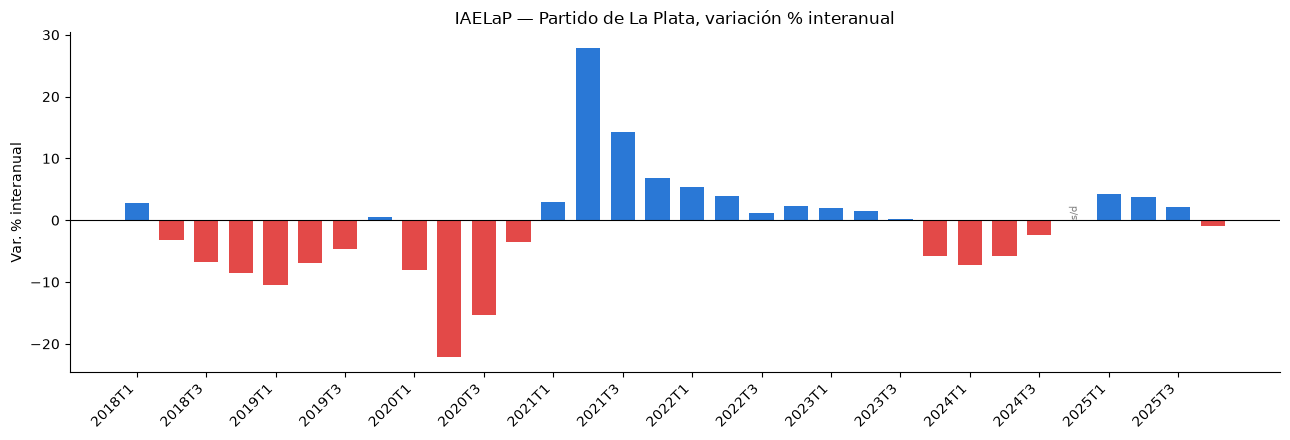

In [12]:
fig = g.graficar_iaelap_general(DATOS)
fig.savefig(SALIDA / "iaelap_general.png", dpi=150)
print("guardado:", SALIDA / "iaelap_general.png")

## 3. IAELaP — desagregación sectorial

Barras horizontales coloreadas por signo (no por identidad de rama — con ~15 ramas, una paleta categórica cicla, que la skill de dataviz prohíbe). Dos cortes: el último trimestre relevado (4T2025) y el acumulado anual 2025.

guardado: /workspaces/analisis-politica-economia/graficos/socioeconomia/iaelap_sectorial_4t2025.png


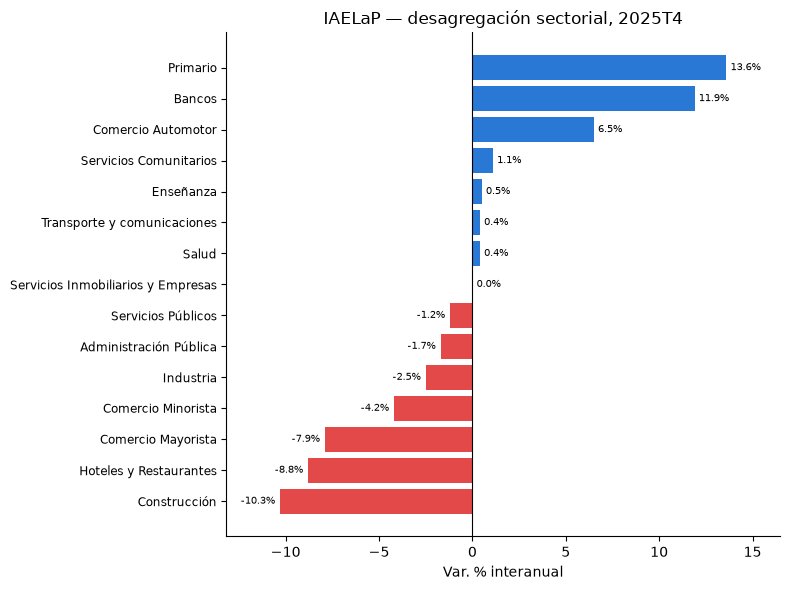

In [13]:
fig = g.graficar_iaelap_sectorial(DATOS, "trimestral", 2025, 4)
fig.savefig(SALIDA / "iaelap_sectorial_4t2025.png", dpi=150)
print("guardado:", SALIDA / "iaelap_sectorial_4t2025.png")

guardado: /workspaces/analisis-politica-economia/graficos/socioeconomia/iaelap_sectorial_2025.png


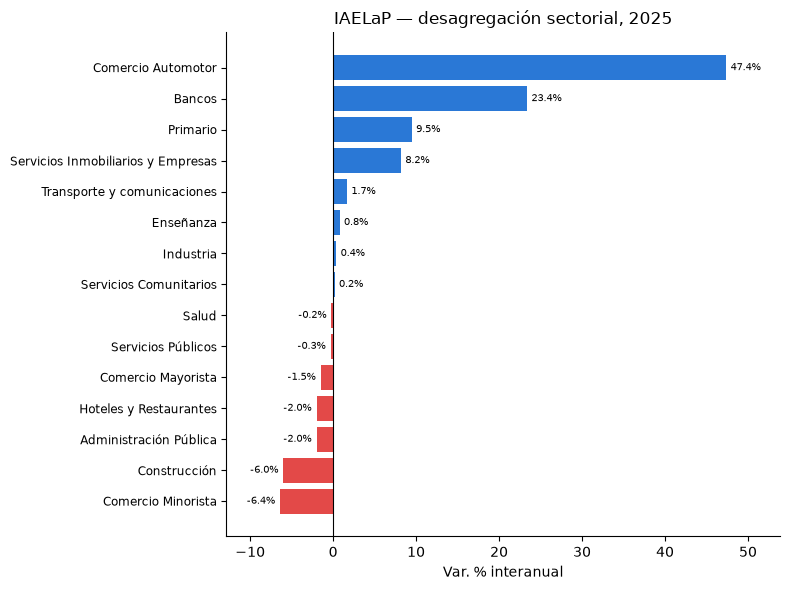

In [14]:
fig = g.graficar_iaelap_sectorial(DATOS, "anual", 2025)
fig.savefig(SALIDA / "iaelap_sectorial_2025.png", dpi=150)
print("guardado:", SALIDA / "iaelap_sectorial_2025.png")

## 4. Contraste EPH vs. IAELaP

Paneles apilados, mismo eje temporal, **sin dual-axis** — geografías distintas (aglomerado vs. partido), no se superponen en un único eje.

guardado: /workspaces/analisis-politica-economia/graficos/socioeconomia/contraste_eph_iaelap.png


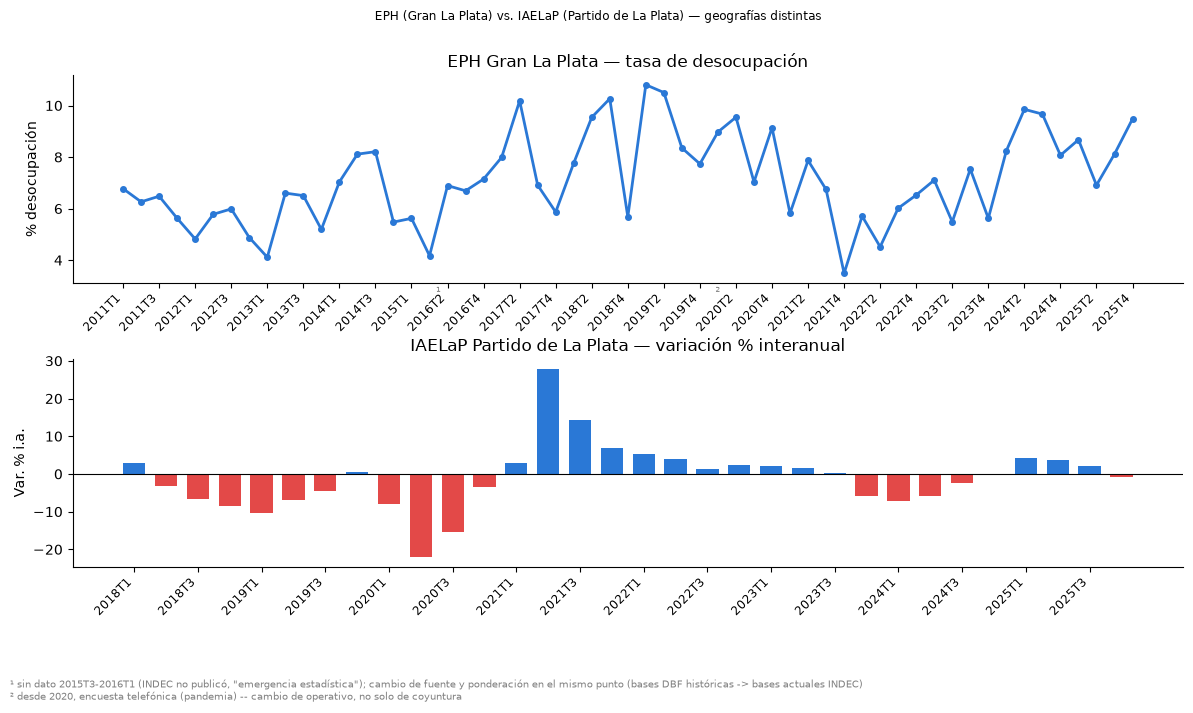

In [15]:
fig = g.graficar_contraste_eph_iaelap(DATOS)
fig.savefig(SALIDA / "contraste_eph_iaelap.png", dpi=150)
print("guardado:", SALIDA / "contraste_eph_iaelap.png")

## Nota: validación cruzada encontrada entre EPH e IAELaP

El boletín IAELaP 4T2025 cita textualmente, del INDEC (EPH): tasa de desempleo Gran La Plata **8,1% en 4T2024 → 9,5% en 4T2025**. La serie propia calculada en `eph_gran_la_plata.csv` (independiente, construida en el notebook 05 a partir de microdatos crudos) da:

In [16]:
import csv

with open(DATOS / "eph_gran_la_plata.csv") as f:
    filas = {(int(r["anio"]), int(r["trimestre"])): r for r in csv.DictReader(f)}

for anio, trimestre in [(2024, 4), (2025, 4)]:
    tasa = float(filas[(anio, trimestre)]["tasa_desocupacion"])
    print(f"{anio}T{trimestre}: {tasa:.1%} (propio) vs. cifra citada por IAELaP: "
          f"{'8,1%' if (anio, trimestre) == (2024, 4) else '9,5%'}")

2024T4: 8.1% (propio) vs. cifra citada por IAELaP: 8,1%
2025T4: 9.5% (propio) vs. cifra citada por IAELaP: 9,5%


Prácticamente idéntico pese a ser dos cálculos independientes (mismo microdato EPH, procesado por separado) — buena señal de que el pipeline de `eph_client.py`/`agregados_gran_la_plata` es correcto.